In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import xgboost as xgb

In [2]:
df = pd.read_csv('../data/features_data.csv')

In [3]:
features_to_keep = [
    'Date', 'home_team', 'away_team', 'target',
    'B365H', 'B365D', 'B365A',
    'home_team_goals_avg_last_5', 'away_goals_avg_last_5', 
    'home_goals_conceded_avg_last_5', 'away_goals_conceded_avg_last_5',
    'ht_home_goals_avg_last_5', 'ht_away_goals_avg_last_5',
    'home_form_1h_last_5', 'away_form_1h_last_5', 'home_form_2h_last_5', 'away_form_2h_last_5',
    'home_shots_avg_last_5', 'away_shots_avg_last_5', 
    'home_shots_target_avg_last_5', 'away_shots_target_avg_last_5',
    'home_red_cards_avg_last_5', 'away_red_cards_avg_last_5',
    'home_points_avg_last_5', 'away_points_avg_last_5', 
    'home_overall_points_last_5', 'away_overall_points_last_5'
]

In [4]:
df_final = df[features_to_keep].copy()
df_final.dropna(inplace=True)
df_final['Date'] = pd.to_datetime(df_final['Date'])
df_final = df_final.sort_values('Date')

In [5]:
X = df_final.drop(columns=['Date', 'home_team', 'away_team', 'target']).copy()
y = df_final['target'].copy()
print(X.info())

<class 'pandas.DataFrame'>
Index: 271 entries, 20 to 290
Data columns (total 23 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   B365H                           271 non-null    float64
 1   B365D                           271 non-null    float64
 2   B365A                           271 non-null    float64
 3   home_team_goals_avg_last_5      271 non-null    float64
 4   away_goals_avg_last_5           271 non-null    float64
 5   home_goals_conceded_avg_last_5  271 non-null    float64
 6   away_goals_conceded_avg_last_5  271 non-null    float64
 7   ht_home_goals_avg_last_5        271 non-null    float64
 8   ht_away_goals_avg_last_5        271 non-null    float64
 9   home_form_1h_last_5             271 non-null    float64
 10  away_form_1h_last_5             271 non-null    float64
 11  home_form_2h_last_5             271 non-null    float64
 12  away_form_2h_last_5             271 non-null    flo

In [6]:

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(solver='lbfgs', max_iter=1000)

log_reg.fit(X_train_scaled, y_train)

log_preds = log_reg.predict(X_test_scaled)
log_acc = accuracy_score(y_test, log_preds)

print(f"Logistic Regression Accuracy: {log_acc:.2%}")

NameError: name 'X_train' is not defined

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

Training samples: 216
Testing samples: 55


In [ ]:
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)

param_grid = {
    'n_estimators': [50, 100, 200],        
    'max_depth': [None, 5, 10],           
    'min_samples_split': [2, 5, 10],       
    'criterion': ['gini', 'entropy']      
}

rf = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(estimator=rf, 
                           param_grid=param_grid, 
                           cv=tscv, 
                           scoring='accuracy', 
                           n_jobs=-1, 
                           verbose=1)

grid_search.fit(X_train, y_train)

print(f"best params: {grid_search.best_params_}")
print(f"best Accuracy: {grid_search.best_score_:.2%}")


best_rf_model = grid_search.best_estimator_
final_test_acc = best_rf_model.score(X_test, y_test)
print(f"Final Accuracy on testing set: {final_test_acc:.2%}")

Fitting 5 folds for each of 54 candidates, totalling 270 fits
best params: {'criterion': 'gini', 'max_depth': None, 'min_samples_split': 10, 'n_estimators': 50}
best Accuracy: 49.44%
Final Accuracy on testing set: 47.27%


In [ ]:
importances = model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
print(feature_importance_df)

                           Feature  Importance
2                            B365A    0.078387
13           home_shots_avg_last_5    0.063511
14           away_shots_avg_last_5    0.060882
0                            B365H    0.059142
16    away_shots_target_avg_last_5    0.056151
21      home_overall_points_last_5    0.051971
15    home_shots_target_avg_last_5    0.051178
19          home_points_avg_last_5    0.047448
11             home_form_2h_last_5    0.047359
4            away_goals_avg_last_5    0.046554
12             away_form_2h_last_5    0.043843
9              home_form_1h_last_5    0.042086
5   home_goals_conceded_avg_last_5    0.041721
1                            B365D    0.041490
3       home_team_goals_avg_last_5    0.040821
6   away_goals_conceded_avg_last_5    0.039851
22      away_overall_points_last_5    0.039231
20          away_points_avg_last_5    0.037783
10             away_form_1h_last_5    0.034265
7         ht_home_goals_avg_last_5    0.030893
8         ht_

In [ ]:

xgb_model = xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, 
                              eval_metric='mlogloss', random_state=42)

xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)
xgb_acc = accuracy_score(y_test, xgb_preds)

print(f"XGBoost Accuracy: {xgb_acc:.2%}")

XGBoost Accuracy: 47.27%


C:\Users\huber\AppData\Local\Temp\ipykernel_8728\1136935320.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(x=models, y=scores, palette='viridis')


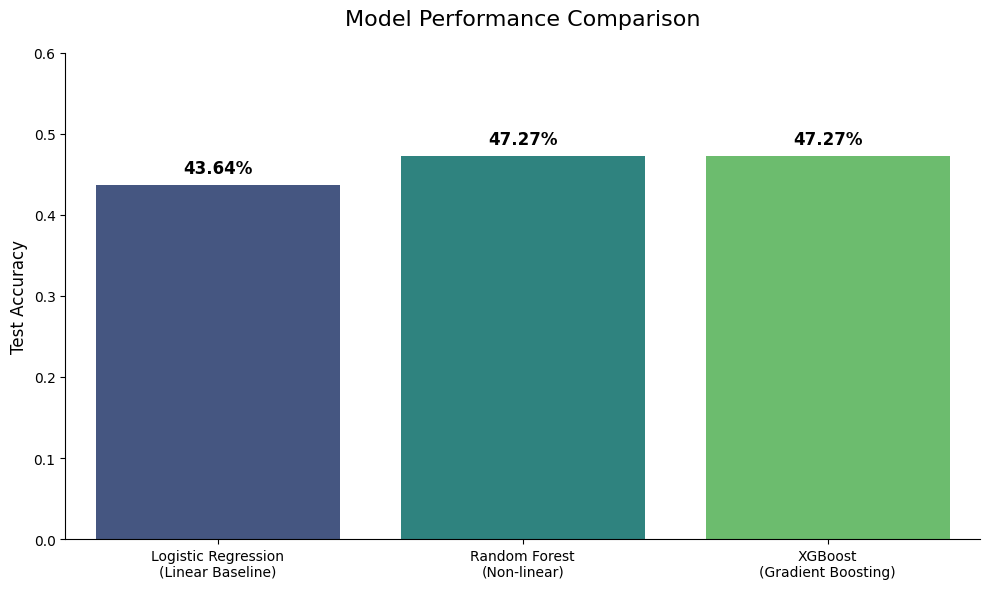

In [ ]:
import matplotlib.pyplot as plt


models = ['Logistic Regression\n(Linear Baseline)', 'Random Forest\n(Non-linear)', 'XGBoost\n(Gradient Boosting)']
scores = [log_acc, accuracy, xgb_acc] 

plt.figure(figsize=(10, 6))
bars = sns.barplot(x=models, y=scores, palette='viridis')


plt.title('Model Performance Comparison', fontsize=16, pad=20)
plt.ylabel('Test Accuracy', fontsize=12)
plt.ylim(0, 0.6) # Oś Y do 60%


for bar in bars.patches:
    plt.text(bar.get_x() + bar.get_width() / 2, 
             bar.get_height() + 0.01, 
             f"{bar.get_height():.2%}", 
             ha='center', va='bottom', fontsize=12, fontweight='bold')


sns.despine()
plt.tight_layout()
plt.show()

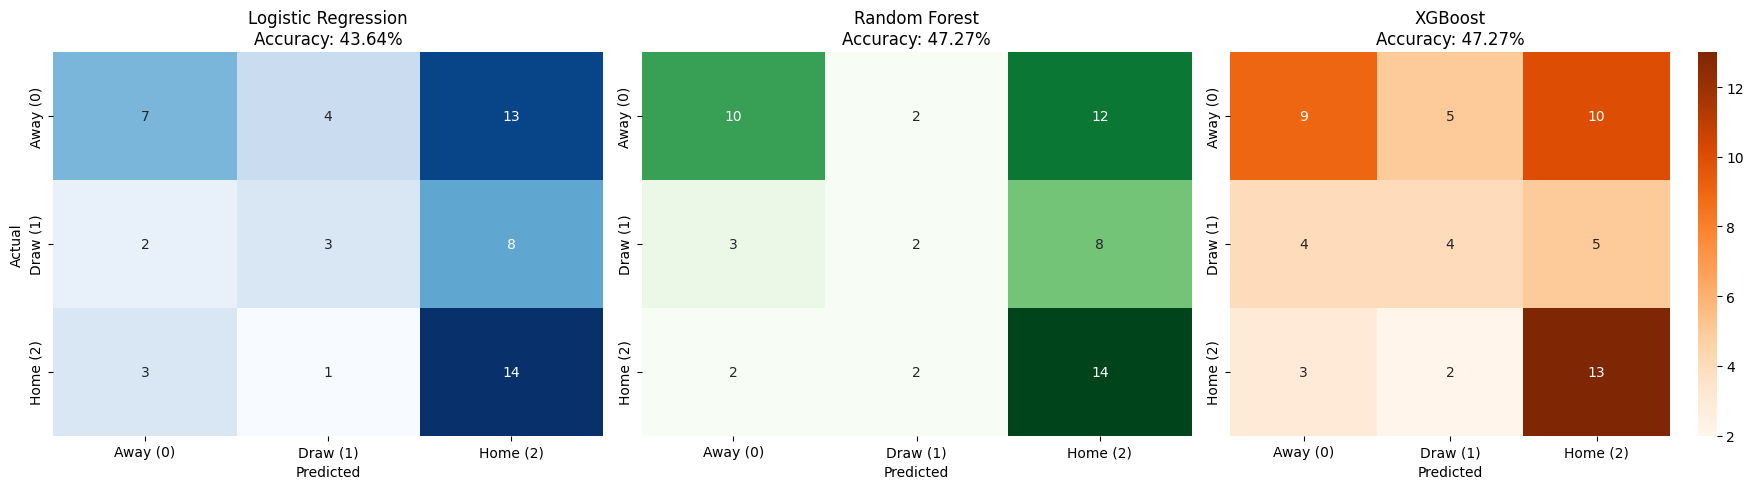

In [ ]:

cm_log = confusion_matrix(y_test, log_preds)
cm_rf = confusion_matrix(y_test, predictions) 
cm_xgb = confusion_matrix(y_test, xgb_preds)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
labels = ['Away (0)', 'Draw (1)', 'Home (2)']

sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues', ax=axes[0], 
            xticklabels=labels, yticklabels=labels, cbar=False)
axes[0].set_title('Logistic Regression\nAccuracy: 43.64%')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[1], 
            xticklabels=labels, yticklabels=labels, cbar=False)
axes[1].set_title('Random Forest\nAccuracy: 47.27%')
axes[1].set_xlabel('Predicted')

sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges', ax=axes[2], 
            xticklabels=labels, yticklabels=labels)
axes[2].set_title('XGBoost\nAccuracy: 47.27%')
axes[2].set_xlabel('Predicted')

plt.tight_layout()
plt.show()

In [ ]:
import joblib
joblib.dump(xgb_model, '../models/xgboost_football_model.pkl')
joblib.dump(cols_to_use, '../models/model_features.pkl')

XGBoost model saved successfully.
Random Forest model saved successfully.
Feature list saved successfully.
File 3 completed. Models are ready for deployment.
